# Preprocessing

## 1. Consolidate individual datasets

### (a) Loading individual datasets

In [1]:
import pandas as pd
import os

# Check user is running this script from the 'engg2112' home directory.
current_folder = os.path.basename(os.getcwd())
if current_folder != "engg2112":
    print("Error: Please run this script from the 'engg2112' home directory.")
    exit()  # Stops the script immediately

FUEL_FILE = "datasets/fuel/NSW_E10_Full_Year_25_26.csv"
WEATHER_FILE = "datasets/weather/year_weather_dataset.csv"
OIL_FILE = "datasets/oil/daily oil price.xlsx"
TGP_FILE = "datasets/tgp/petrol_tgp.csv"
FX_FILE = "datasets/exchange/2023-current.xls"
COMPLETE_OUTPUT_FILE = "datasets/YEAR_COMPLETE_DATASET.csv"
MODEL_READY_OUTPUT_FILE = "datasets/MODEL_READY_DATASET5.csv"

fuel_df = pd.read_csv(FUEL_FILE)
weather_df = pd.read_csv(WEATHER_FILE)
oil_df = pd.read_excel(OIL_FILE)
tgp_df = pd.read_csv(TGP_FILE)

# FX Data has unique formatting (metadata in top 11 rows)
fx_df_raw = pd.read_excel(FX_FILE, skiprows=1, nrows=0) # Get headers
fx_df = pd.read_excel(FX_FILE, skiprows=11, names=fx_df_raw.columns) # Get data

### (b) Standardising dates between datasets

In [2]:
# Convert Fuel Date - using mixed format and dayfirst for Australian/UK style dates
fuel_df['date'] = pd.to_datetime(
    fuel_df['PriceUpdatedDate'], 
    dayfirst=True, 
    format='mixed'
)

# Convert Weather Date
weather_df['date'] = pd.to_datetime(weather_df['date'])

# Convert Oil Date
oil_df['date'] = pd.to_datetime(oil_df['date'])

# Convert TGP Date (First column is date)
tgp_date_col = tgp_df.columns[0]
tgp_df['date'] = pd.to_datetime(tgp_df[tgp_date_col])

# Convert FX Date (First column is date)
date_col = fx_df.columns[0]
fx_df['date'] = pd.to_datetime(fx_df[date_col], errors='coerce')

# fx dataset can be problematic; if datetime conversion fails, try Excel serial conversion
if fx_df['date'].isna().all():
    numeric_vals = pd.to_numeric(fx_df[date_col], errors='coerce')
    fx_df['date'] = pd.to_datetime(numeric_vals, unit='D', origin='1899-12-30')

# Drop rows that have no 'date' column (e.g., headers/footers) in this problematic csv
fx_df = fx_df.dropna(subset=['date'])

# Normalise all dates; so that time during day doesn't matter
df_list = [fuel_df, weather_df, oil_df, tgp_df, fx_df]
for df in df_list:
    df['date'] = df['date'].dt.normalize()

### (c) Rename and prepare columns for merging

In [3]:
oil_df = oil_df.rename(columns={'price': 'oil_price'})
tgp_df = tgp_df[['date', 'sydney_tgp']].rename(columns={'sydney_tgp': 'tgp_sydney'})

# Finding which column in fx_df.csv is the aud/usd column?
fx_col_candidates = [col for col in fx_df.columns if 'usd' in col.lower()]
if not fx_col_candidates:
    raise ValueError("Could not find AUD/USD column in FX dataset")

# There should just be one; either way take the first column as aud/usd
fx_col = fx_col_candidates[0]
fx_df = fx_df[['date', fx_col]].rename(columns={fx_col: 'aud_usd'})

# For adding a new column "region" into fuel_df
def assign_region(postcode):
    """Maps postcodes to your 6 specific weather regions"""
    try:
        p = int(postcode)
        if 2745 <= p <= 2780: return "Western_Sydney"
        elif (2170 <= p <= 2179) or (2560 <= p <= 2579): return "South_West_Sydney"
        elif (2250 <= p <= 2330) or (2280 <= p <= 2319): return "Hunter"
        elif 2500 <= p <= 2530: return "Wollongong"
        elif (2600 <= p <= 2620) or (2900 <= p <= 2914): return "Canberra"
        elif 2000 <= p <= 2199: return "Sydney_CBD"
        else: return "Regional"
    except:
        return "Regional"

# This is necessary so that can merge with weather_df, that only has region (not postcode)
fuel_df['Region'] = fuel_df['Postcode'].apply(assign_region)

### (d) Merging individual datasets 

In [4]:
# First merge fuel and weather df using the constructed 'Region' column
df_final = pd.merge(fuel_df, weather_df, on=['date', 'Region'], how='inner')

# Then, merge that with everything else using the standardised 'Date' column
df_final = pd.merge(df_final, oil_df, on='date', how='left')
df_final = pd.merge(df_final, tgp_df, on='date', how='left')
df_final = pd.merge(df_final, fx_df, on='date', how='left')

### (e) Filling weekend gaps in market data

In [5]:
# Market data (Oil, TGP, FX) is missing on weekends. 
# We fill forward so Saturday/Sunday uses Friday's price.
df_final = df_final.sort_values(by=['date', 'ServiceStationName'])
cols_to_fill = ['oil_price', 'tgp_sydney', 'aud_usd']
df_final[cols_to_fill] = df_final[cols_to_fill].ffill().bfill()

### (e') --- HARD THRESHOLD FILTERING ---

In [6]:
# Before saving, let's make all columns lowercase
df_final.columns = [col.lower() for col in df_final.columns]
df_final = df_final.rename(columns={'price': 'fuel_price'})

# --- HARD THRESHOLD FILTERING ---
# 1. Sort by station and date to ensure consecutive days line up correctly
# FIX: Use lowercase 'servicestationname'
df_final = df_final.sort_values(by=['servicestationname', 'date']).reset_index(drop=True)

# 2. Calculate the daily price change per individual service station
# FIX: Use lowercase 'servicestationname' and 'fuel_price'
df_final['price_change'] = df_final.groupby('servicestationname')['fuel_price'].diff()

# 3. Filter out rows where the absolute change is greater than 40 cents ($0.40)
threshold = 40
filter_condition = (df_final['price_change'].abs() <= threshold) | (df_final['price_change'].isna())

# Record count before filtering for tracking
rows_before = len(df_final)

# Apply the filter
df_final = df_final[filter_condition].copy()

# Drop the temporary price_change column so it doesn't clutter your output
df_final = df_final.drop(columns=['price_change'])

print(f"Filter Applied: Removed {rows_before - len(df_final)} rows with a daily price change > {threshold} cents.")
# --------------------------------

Filter Applied: Removed 5249 rows with a daily price change > 40 cents.


### (f) Saving complete dataset to output file

In [7]:
# Before saving, let's make all columns lowercase
df_final.columns = [col.lower() for col in df_final.columns]
df_final = df_final.rename(columns={'price': 'fuel_price'})

# And then do the save
output_dir = os.path.dirname(COMPLETE_OUTPUT_FILE)
if output_dir:
    os.makedirs(output_dir, exist_ok=True)
df_final.to_csv(COMPLETE_OUTPUT_FILE, index=False)

print("-" * 80)
print(f"SUCCESS: {COMPLETE_OUTPUT_FILE} is ready.")
print("-" * 80)

df_final.info()

--------------------------------------------------------------------------------
SUCCESS: datasets/YEAR_COMPLETE_DATASET.csv is ready.
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 155198 entries, 0 to 160446
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   servicestationname  155198 non-null  object        
 1   address             155198 non-null  object        
 2   suburb              155198 non-null  object        
 3   postcode            155198 non-null  int64         
 4   brand               155198 non-null  object        
 5   fuelcode            155198 non-null  object        
 6   priceupdateddate    155198 non-null  object        
 7   fuel_price          155198 non-null  float64       
 8   date                155198 non-null  datetime64[ns]
 9   region              155198 non-null  object   

## 2. Generate feature columns

### (a') Plots for deciding Rolling Averages/Time Lags

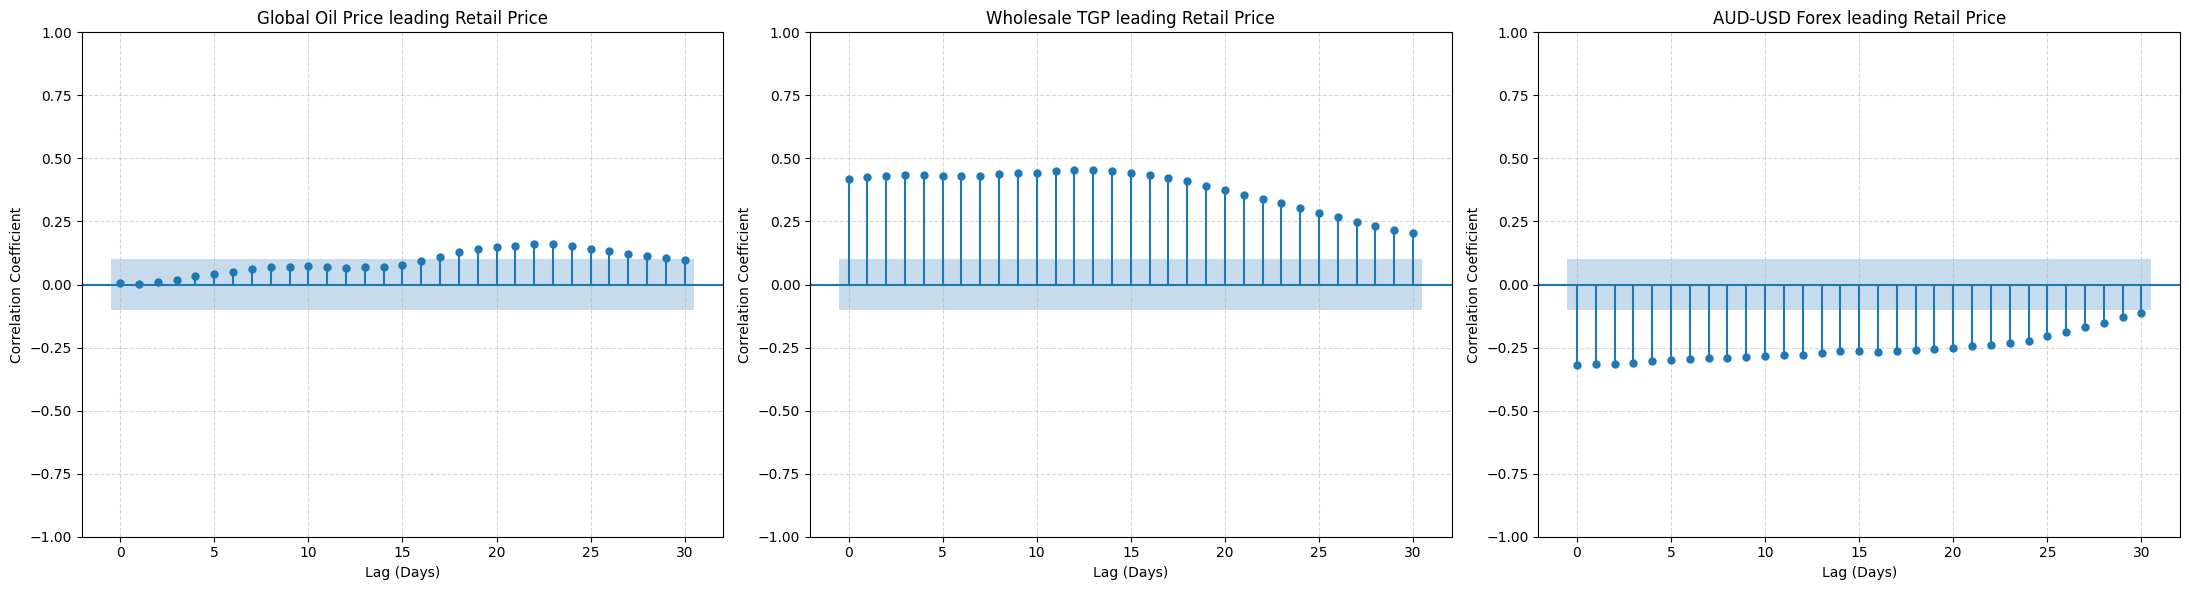

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_ccf

# 1. Group by date and calculate the mean safely for all macro drivers
df_daily = df_final.groupby('date').mean(numeric_only=True).sort_index()

# 2. Extract and drop rows missing any of our critical economic variables
df_macro = df_daily[['oil_price', 'tgp_sydney', 'aud_usd', 'fuel_price']].dropna()

# Extract the individual signals
fuel_signal = df_macro['fuel_price']
oil_signal = df_macro['oil_price']
tgp_signal = df_macro['tgp_sydney']
aud_signal = df_macro['aud_usd']

# 3. Set up a 1-row, 3-column side-by-side subplot layout
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Panel 1: Global Oil Price ---
plot_ccf(fuel_signal, oil_signal, lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title("Global Oil Price leading Retail Price")
axes[0].set_xlabel("Lag (Days)")
axes[0].set_ylabel("Correlation Coefficient")
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Panel 2: Wholesale Sydney TGP ---
plot_ccf(fuel_signal, tgp_signal, lags=30, ax=axes[1], alpha=0.05)
axes[1].set_title("Wholesale TGP leading Retail Price")
axes[1].set_xlabel("Lag (Days)")
axes[1].set_ylabel("Correlation Coefficient")
axes[1].grid(True, linestyle='--', alpha=0.5)

# --- Panel 3: AUD-USD Exchange Rate ---
plot_ccf(fuel_signal, aud_signal, lags=30, ax=axes[2], alpha=0.05)
axes[2].set_title("AUD-USD Forex leading Retail Price")
axes[2].set_xlabel("Lag (Days)")
axes[2].set_ylabel("Correlation Coefficient")
axes[2].grid(True, linestyle='--', alpha=0.5)

# 4. Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

#### Panel 1: Global Oil Price (The Macro Wave)

What the graph shows: A very slow, gradual rise that peaks around Lags 18 to 22 at a correlation of $\sim 0.15$.

The Economic Justification: Global crude oil takes roughly 3 weeks to be bought, shipped across oceans, refined, distributed, and priced into local pumps. Short-term lags (0 to 5) are inside the blue shaded zone of insignificance.

Feature Engineering Verdict: Justified. Trashing oil_price_lag_1 and replacing it with oil_price_lag_19, oil_price_lag_21, and your rolling oil_price_lag_19_to_22_mean is 100% mathematically supported by this peak.

#### Panel 2: Wholesale TGP (The Direct Engine)

What the graph shows: A massive, immediate leap starting right at Lag 0 and Lag 1, holding an incredibly high and statistically significant correlation ($\sim 0.45$) that stays strong for over two weeks.

The Economic Justification: Terminal Gate Prices (TGP) represent domestic wholesale prices right at the Sydney refinery gates. Retailers track this daily. Because it has already absorbed the 3-week global shipping delay under the hood, any sudden jump in wholesale prices yesterday hits the retail station pumps almost instantly.

Feature Engineering Verdict: Highly Justified. Keeping tgp_sydney_lag_1 is absolutely essential. It captures immediate wholesale shocks that dictate retail adjustments the very next morning.

#### Panel 3: AUD-USD Forex (The Inverse Lever)

What the graph shows: A strong, immediate negative correlation ($\sim -0.30$) starting right at Lag 0 and Lag 1 and slowly decaying over the 30-day window.

The Economic Justification: This negative correlation makes perfect economic sense. Because oil is traded globally in US Dollars, a higher AUD-USD exchange rate means the Australian Dollar is stronger. A stronger AUD means it costs fewer Australian dollars to buy the same barrel of oil, driving domestic wholesale and retail fuel costs down. Therefore, as AUD-USD goes up, retail fuel price goes down (hence the negative correlation).

Feature Engineering Verdict: Highly Justified. Because currency markets move instantly and influence daily wholesale import pricing indexes, capturing aud_usd_lag_1 is mathematically perfect for giving your Random Forest model immediate context on currency purchasing power.

Summary for Your Project: This multi-plot completely validates your pipeline, that
- Global Oil provides the long-term macroeconomic baseline (via 19–22 day lags).
- Wholesale TGP provides the immediate local pricing pressure (via 1-day lag).
- AUD-USD Forex provides the immediate currency-scaling factor (via 1-day lag).

### (a) Daily and weekly average features

In [9]:
# For each (postcode, date) pair, what is the average of all prices; rows that have (postcode, date)
daily_avg_df = df_final.groupby(['postcode', 'date'])['fuel_price'].mean().reset_index()

# This is a new df isn't it; daily_avg_df. Rename the price column within this to postcode_daily_avg
daily_avg_df.rename(columns={'fuel_price': 'fuel_postcode_daily_avg'}, inplace=True)

# Sort to ensure the timeline is chronological for the rolling calculation
daily_avg_df = daily_avg_df.sort_values(['postcode', 'date'])

# We shift the average by 1 day so 'today' has access to 'yesterday's' price
daily_avg_df['fuel_postcode_price_lag_1'] = daily_avg_df.groupby('postcode')['fuel_postcode_daily_avg'].shift(1)

# Make new column that is 7-day rolling average
daily_avg_df['fuel_postcode_rolling_7d'] = daily_avg_df.groupby('postcode')['fuel_postcode_daily_avg'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Drop rows where lag is NaN (the very first day of your dataset)
daily_avg_df = daily_avg_df.dropna(subset=['fuel_postcode_price_lag_1'])

# Merge new daily_avg_df with old df_final
df_final = df_final.merge(daily_avg_df, on=['postcode', 'date'], how='left')

### (b) Time lag features

In [10]:
# Making sure there is just one oil_price, tgp_sydney, and aud_usd for each date
lag_df = df_final.groupby('date')[['oil_price', 'tgp_sydney', 'aud_usd']].mean().reset_index()

# And sort by date so that can then calculate the time lag features
lag_df = lag_df.sort_values('date')

# 1. Keep your 7-day rolling averages (they act as great low-pass filters)
lag_df['oil_rolling_7d'] = lag_df['oil_price'].rolling(window=7, min_periods=1).mean()
lag_df['tgp_rolling_7d'] = lag_df['tgp_sydney'].rolling(window=7, min_periods=1).mean()
lag_df['aud_usd_rolling_7d'] = lag_df['aud_usd'].rolling(window=7, min_periods=1).mean()

# 2. Short-term Lags: Essential for Wholesale TGP which hits retail much faster
lag_df['tgp_sydney_lag_1'] = lag_df['tgp_sydney'].shift(1)
lag_df['aud_usd_lag_1'] = lag_df['aud_usd'].shift(1)

# 3. NEW FEATURE ENGINEERING: Capture the 3-week global oil lag mountain
# Based on your CCF plot peak at Lags 19-22
lag_df['oil_price_lag_19'] = lag_df['oil_price'].shift(19)
lag_df['oil_price_lag_21'] = lag_df['oil_price'].shift(21)

# Capture the entire peak window as a smoothed macro-indicator
lag_df['oil_price_lag_19_to_22_mean'] = lag_df['oil_price'].shift(19).rolling(window=4).mean()

# 4. Define all your engineered feature columns to merge back
cols_to_fix = [
    'tgp_sydney_lag_1', 'aud_usd_lag_1',
    'oil_rolling_7d', 'tgp_rolling_7d', 'aud_usd_rolling_7d',
    'oil_price_lag_19', 'oil_price_lag_21', 'oil_price_lag_19_to_22_mean'
]

# Use bfill() to gracefully handle the empty rows created at the start of your timeline by the deep shifts
lag_df[cols_to_fix] = lag_df[cols_to_fix].bfill()

# Take the subset ['date' + cols_to_fix] of lag_df, and merge with original df_final
df_final = df_final.merge(lag_df[['date'] + cols_to_fix], on='date', how='left')

### (c) OTHERS


In [11]:
import numpy as np

# --- 2. Engineering Features Section ---
print("2. Engineering Features...")

# Dynamic Features
df_final['retail_margin'] = df_final['fuel_price'] - df_final['tgp_sydney']

# Ensure sorting is correct by station and lowercase 'date'
df_final = df_final.sort_values(['servicestationname', 'date']).reset_index(drop=True)

# 1. Price Change 24h (Calculated per station)
df_final['price_change_24h'] = df_final.groupby('servicestationname')['fuel_price'].diff().fillna(0)

# 2. Averages (Calculated per postcode and date)
daily_avg = df_final.groupby(['postcode', 'date'])['fuel_price'].mean().reset_index().rename(columns={'fuel_price': 'post_avg'})
daily_avg['post_roll_7'] = daily_avg.groupby('postcode')['post_avg'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df_final = df_final.merge(daily_avg, on=['postcode', 'date'], how='left')

# 3. Cyclical Time Encodings (Replacing day_of_week)
df_final['day_of_week'] = df_final['date'].dt.dayofweek
df_final['day_sin'] = np.sin(2 * np.pi * df_final['day_of_week'] / 7.0)
df_final['day_cos'] = np.cos(2 * np.pi * df_final['day_of_week'] / 7.0)

# 4. Is Hike Day & Interactions
df_final['is_hike_day'] = (df_final['price_change_24h'] > 15.0).astype(int)
df_final['margin_hike_interaction'] = df_final['retail_margin'] * df_final['is_hike_day']

2. Engineering Features...


### (d) Target feature

In [12]:
# 1. Calculate tomorrow's average price
daily_avg_df = daily_avg_df.sort_values(['postcode', 'date'])
daily_avg_df['target_fuel_price_tomorrow'] = daily_avg_df.groupby('postcode')['fuel_postcode_daily_avg'].shift(-1)

# 2. Safety Check: Get the date of that shifted price
daily_avg_df['target_date'] = daily_avg_df.groupby('postcode')['date'].shift(-1)

# 3. Only keep rows where the gap is exactly 1 day
# This prevents "jumping" over missing dates
is_consecutive = (daily_avg_df['target_date'] - daily_avg_df['date']).dt.days == 1
daily_avg_df = daily_avg_df[is_consecutive]

# 4. Merge the clean target back into df_final
df_final = df_final.merge(
    daily_avg_df[['postcode', 'date', 'target_fuel_price_tomorrow']], 
    on=['postcode', 'date'], 
    how='left'
)

# 5. Drop rows where no valid consecutive tomorrow exists
df_final = df_final.dropna(subset=['target_fuel_price_tomorrow'])

# Clean up temp column
daily_avg_df = daily_avg_df.drop(columns=['target_date'])

### (e) Saving model-ready dataset to output file

In [13]:
# Removing non-number and non-boolean columns; irrelevant to model training
cols_to_drop = [
    'servicestationname', 
    'address', 
    'suburb', 
    'region', 
    'date',
    'priceupdateddate',
    'brand',
    'fuelcode'
]
df_final = df_final.sort_values('date')
df_final = df_final.drop(columns=cols_to_drop)

# # Remove identical rows
# df_final = df_final.drop_duplicates()

df_final = df_final.dropna()
df_final.to_csv(MODEL_READY_OUTPUT_FILE, index=False)

print("-" * 80)
print(f"SUCCESS: {MODEL_READY_OUTPUT_FILE} is ready.")
print("-" * 80)
df_final.info()

--------------------------------------------------------------------------------
SUCCESS: datasets/MODEL_READY_DATASET5.csv is ready.
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 133540 entries, 118702 to 147018
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   postcode                     133540 non-null  int64  
 1   fuel_price                   133540 non-null  float64
 2   temp_max                     133540 non-null  float64
 3   temp_min                     133540 non-null  float64
 4   rainfall                     133540 non-null  float64
 5   oil_price                    133540 non-null  float64
 6   tgp_sydney                   133540 non-null  float64
 7   aud_usd                      133540 non-null  float64
 8   fuel_postcode_daily_avg      133540 non-null  float64
 9   fuel_postcode_price_

# Training

## 3. Initial modelling and comparison with baseline

### (a) Load model-ready dataset and do train-test split

In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler # <-- Import Scaler
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load the exact same dataset
df = pd.read_csv(MODEL_READY_OUTPUT_FILE)

# 2. Apply the SAME Chronological Split (80% Train, 20% Test)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# 3. Separate features and target
target_col = 'target_fuel_price_tomorrow'
X_train_chrono = train_df.drop(columns=[target_col])
y_train_chrono = train_df[target_col]
X_test_chrono = test_df.drop(columns=[target_col])
y_test_chrono = test_df[target_col]

# === SAFE CHRONOLOGICAL SCALING SECTION ===
# Initialize the standardizer (Z-score normalization)
scaler = StandardScaler()

# CRITICAL: Fit only on the past training data, then transform it
X_train_scaled = scaler.fit_transform(X_train_chrono)

# CRITICAL: Use the training parameters to transform the unseen future test vault
X_test_scaled = scaler.transform(X_test_chrono)
# ==========================================

# 4. Instantiate and Train the Baseline Linear Regression (Using SCALED data)
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_scaled, y_train_chrono)

# 5. Generate Predictions on the future test vault
baseline_preds = baseline_lr.predict(X_test_scaled)

# 6. Calculate your honest scaled linear baseline metrics
baseline_mae = mean_absolute_error(y_test_chrono, baseline_preds)
baseline_r2 = r2_score(y_test_chrono, baseline_preds)


# 7. Instantiate and Train Random Forest (Using UNSCALED data)
baseline_rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    bootstrap=True,
    random_state=42, 
    n_jobs=-1
)
# We feed the raw, unscaled features here because trees are scale-invariant
baseline_rf.fit(X_train_chrono, y_train_chrono)
baseline_rf_preds = baseline_rf.predict(X_test_chrono)

baseline_rf_mae = mean_absolute_error(y_test_chrono, baseline_rf_preds)
baseline_rf_r2 = r2_score(y_test_chrono, baseline_rf_preds)

print("--- Updated Baseline Random Forest (Unscaled Chronological Split) ---")
print(f"Baseline RF MAE: {baseline_rf_mae:.4f} cents")
print(f"Baseline RF R2:  {baseline_rf_r2:.4f}\n")

print("--- Updated Baseline Linear Regression (Scaled Chronological Split) ---")
print(f"Baseline Linear Regression MAE: {baseline_mae:.4f} cents")
print(f"Baseline Linear Regression R2:  {baseline_r2:.4f}\n")

--- Updated Baseline Random Forest (Unscaled Chronological Split) ---
Baseline RF MAE: 6.3356 cents
Baseline RF R2:  0.4782

--- Updated Baseline Linear Regression (Scaled Chronological Split) ---
Baseline Linear Regression MAE: 3.3091 cents
Baseline Linear Regression R2:  0.8047



### 📊 Feature Importance & Impact Analysis: Random Forest vs. Linear Regression

To understand *how* our models are predicting tomorrow's fuel prices, we can visualize their internal decision-making parameters side-by-side:

1. **Linear Regression (Standardized Coefficients):** These values represent both **magnitude and direction**. A positive weight means that as the feature increases, tomorrow's fuel price is driven *up* (e.g., higher wholesale TGP). A negative weight means that as the feature increases, tomorrow's price goes *down* (e.g., a stronger AUD/USD exchange rate).
2. **Random Forest (Gini Feature Importance):** These values represent **pure relative importance (0.0 to 1.0)** based on Mean Decrease in Impurity (MDI). It measures how often a specific feature was used to split a tree node and how cleanly it isolated the target variable. Because it is an absolute metric, it does not show direction, only sheer predictive power.

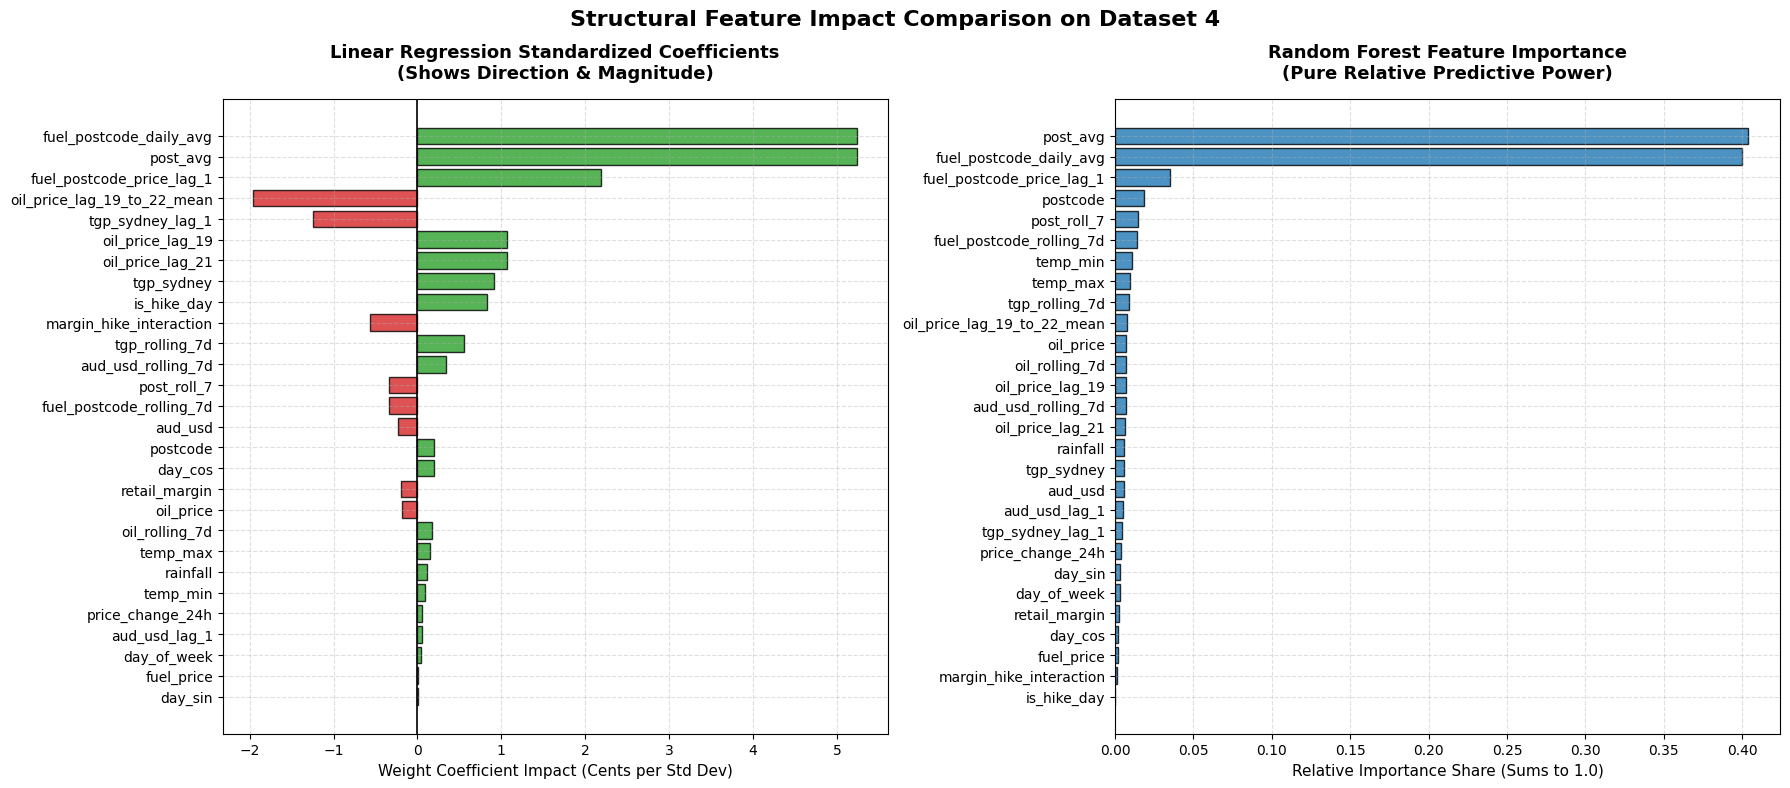

========================================= LINEAR REGRESSION WEIGHTS =========================================
                    Feature  Coefficient
    fuel_postcode_daily_avg     5.241173
                   post_avg     5.241173
  fuel_postcode_price_lag_1     2.188853
oil_price_lag_19_to_22_mean    -1.961925
           tgp_sydney_lag_1    -1.240367
           oil_price_lag_19     1.072016
           oil_price_lag_21     1.068027
                 tgp_sydney     0.906502
                is_hike_day     0.824241
    margin_hike_interaction    -0.571104
             tgp_rolling_7d     0.559843
         aud_usd_rolling_7d     0.339961
                post_roll_7    -0.333663
   fuel_postcode_rolling_7d    -0.333663
                    aud_usd    -0.227381
                   postcode     0.201315
                    day_cos     0.194378
              retail_margin    -0.192067
                  oil_price    -0.180931
             oil_rolling_7d     0.174197
                   temp_max  

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Extract Linear Regression Coefficients
lr_features = X_train_chrono.columns
lr_coefs = baseline_lr.coef_

# Create a DataFrame and sort by absolute magnitude for clean visualization
lr_importance = pd.DataFrame({
    'Feature': lr_features,
    'Coefficient': lr_coefs,
    'Absolute': np.abs(lr_coefs)
}).sort_values(by='Absolute', ascending=True) # Ascending for horizontal bar plot entry

# 2. Extract Random Forest Feature Importances
rf_importances = baseline_rf.feature_importances_

rf_importance = pd.DataFrame({
    'Feature': lr_features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=True)

# 3. Construct Side-by-Side Horizontal Bar Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Panel 1: Linear Regression Coefficients ---
# We map colors: Red for negative price impact, Green for positive price impact
colors = ['#d62728' if c < 0 else '#2ca02c' for c in lr_importance['Coefficient']]

axes[0].barh(lr_importance['Feature'], lr_importance['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1.2)
axes[0].set_title('Linear Regression Standardized Coefficients\n(Shows Direction & Magnitude)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Weight Coefficient Impact (Cents per Std Dev)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Panel 2: Random Forest Feature Importance ---
axes[1].barh(rf_importance['Feature'], rf_importance['Importance'], color='#1f77b4', edgecolor='black', alpha=0.8)
axes[1].set_title('Random Forest Feature Importance\n(Pure Relative Predictive Power)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Relative Importance Share (Sums to 1.0)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

# 4. Global Plot Adjustments
plt.suptitle('Structural Feature Impact Comparison on Dataset 4', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 5. Print out the raw tabular values underneath for precise inspection
print("="*41 + " LINEAR REGRESSION WEIGHTS " + "="*41)
print(lr_importance[['Feature', 'Coefficient']].sort_values(by='Coefficient', key=abs, ascending=False).to_string(index=False))
print("\n" + "="*43 + " RANDOM FOREST IMPURITY " + "="*43)
print(rf_importance.sort_values(by='Importance', ascending=False).to_string(index=False))